#### Exploratory Data Analysis (EDA): Nexora Care Flow Demand Forecasting

In [7]:
# Imports Libaries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns 

In [8]:
# Set visual theme
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [9]:
# load cleaned dataset
df=pd.read_csv(r"C:\Users\Lenovo 2022\OneDrive\Documents\Nexora_care_flow\data\processed\cleaned_AppointmentRecords.csv")

In [10]:
# Info & Summary
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129353 entries, 0 to 129352
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   AppointmentID         129353 non-null  int64 
 1   ClinicID              129353 non-null  int64 
 2   ClinicName            129353 non-null  object
 3   ClinicType            129353 non-null  object
 4   PatientID             129353 non-null  int64 
 5   ProviderID            129353 non-null  int64 
 6   AppointmentDateTime   129353 non-null  object
 7   AppointmentType       129353 non-null  object
 8   Status                129353 non-null  object
 9   BookingChannel        129353 non-null  object
 10  BookingLeadTimeDays   129353 non-null  int64 
 11  IsHoliday             129353 non-null  bool  
 12  HolidayName           129353 non-null  object
 13  SeasonFlag            129353 non-null  object
 14  ChronicConditionFlag  129353 non-null  bool  
dtypes: bool(2), int64

,AppointmentID,ClinicID,PatientID,ProviderID,BookingLeadTimeDays
count,129353.000000,129353.000000,129353.000000,129353.000000,129353.000000
mean,564676.000000,2.417864,103553.485385,245.290005,8.704267
std,37341.139023,1.071525,2020.941152,107.165883,7.641921
min,500000.000000,1.000000,100000.000000,101.000000,0.000000
25%,532338.000000,2.000000,101812.000000,201.000000,3.000000
50%,564676.000000,2.000000,103547.000000,205.000000,7.000000
75%,597014.000000,3.000000,105178.000000,306.000000,12.000000
max,629352.000000,4.000000,107279.000000,406.000000,60.000000


In [23]:
df["AppointmentDateTime"] = pd.to_datetime(df["AppointmentDateTime"])

In [25]:
# aggregate to daily appointment counts across all clinics
daily_counts = df.groupby(df["AppointmentDateTime"].dt.date).size().reset_index(name="AppointmentCount")

daily_counts.head(15)

,AppointmentDateTime,AppointmentCount
0,2024-01-01,31
1,2024-01-02,221
2,2024-01-03,167
3,2024-01-04,171
4,2024-01-05,103
5,2024-01-06,94
6,2024-01-07,12
7,2024-01-08,180
8,2024-01-09,171
9,2024-01-10,180


In [26]:
daily_counts["AppointmentCount"].describe()

count    731.000000
mean     176.953488
std       93.651119
min        7.000000
25%      108.500000
50%      197.000000
75%      249.500000
max      406.000000
Name: AppointmentCount, dtype: float64

In [28]:
daily_counts["AppointmentDateTime"] = pd.to_datetime(daily_counts["AppointmentDateTime"])
daily_counts["DayOfWeek"] = daily_counts["AppointmentDateTime"].dt.day_name()

daily_counts.nsmallest(10, "AppointmentCount")[["AppointmentDateTime", "AppointmentCount", "DayOfWeek"]]

,AppointmentDateTime,AppointmentCount,DayOfWeek
195,2024-07-14,7,Sunday
83,2024-03-24,11,Sunday
202,2024-07-21,11,Sunday
251,2024-09-08,11,Sunday
6,2024-01-07,12,Sunday
146,2024-05-26,12,Sunday
174,2024-06-23,12,Sunday
188,2024-07-07,12,Sunday
55,2024-02-25,13,Sunday
69,2024-03-10,13,Sunday


In [29]:
dow_summary = df.groupby(df["AppointmentDateTime"].dt.day_name()).size()

# put days in proper order instead of alphabetical
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_summary = dow_summary.reindex(day_order)

dow_summary

AppointmentDateTime
Monday       22248
Tuesday      25350
Wednesday    24191
Thursday     22981
Friday       21315
Saturday     11057
Sunday        2211
dtype: int64

In [30]:
# daily appointment count per clinic, plus whether that day was a holiday
clinic_daily = df.groupby(["ClinicName", df["AppointmentDateTime"].dt.date, "IsHoliday"]).size().reset_index(name="AppointmentCount")
clinic_daily.columns = ["ClinicName", "Date", "IsHoliday", "AppointmentCount"]

# average daily volume, holiday vs non-holiday, per clinic
holiday_effect = clinic_daily.groupby(["ClinicName", "IsHoliday"])["AppointmentCount"].mean().unstack()
holiday_effect.columns = ["Avg_NonHoliday", "Avg_Holiday"]
holiday_effect["Pct_Change"] = ((holiday_effect["Avg_Holiday"] - holiday_effect["Avg_NonHoliday"]) / holiday_effect["Avg_NonHoliday"] * 100).round(1)

holiday_effect

,Avg_NonHoliday,Avg_Holiday,Pct_Change
ClinicName,,,
Nexora Care - Downtown Express,35.446809,6.000000,-83.1
Nexora Care - Hillcrest,64.048780,12.285714,-80.8
Nexora Care - Lakeside,75.469218,12.461538,-83.5
Nexora Care - Riverside,48.554077,7.730769,-84.1


In [31]:
# average daily volume by season, per clinic
season_daily = df.groupby(["ClinicName", df["AppointmentDateTime"].dt.date, "SeasonFlag"]).size().reset_index(name="AppointmentCount")
season_daily.columns = ["ClinicName", "Date", "SeasonFlag", "AppointmentCount"]

seasonal_effect = season_daily.groupby(["ClinicName", "SeasonFlag"])["AppointmentCount"].mean().unstack()
seasonal_effect

SeasonFlag,Allergy Season,Flu Season,Standard
ClinicName,,,
Nexora Care - Downtown Express,33.576087,34.530387,34.748634
Nexora Care - Hillcrest,64.518987,70.788462,57.733564
Nexora Care - Lakeside,74.462025,80.666667,68.153355
Nexora Care - Riverside,48.632911,53.961538,42.428115


In [32]:
# total appointments per clinic, and the share of each appointment type within that clinic
type_mix = pd.crosstab(df["ClinicName"], df["AppointmentType"], normalize="index").round(3) * 100
type_mix["TotalAppointments"] = df["ClinicName"].value_counts()

type_mix

AppointmentType,Follow-Up,New Patient,Telehealth,Urgent,TotalAppointments
ClinicName,,,,,
Nexora Care - Downtown Express,34.2,15.2,45.7,4.9,25146
Nexora Care - Hillcrest,44.7,14.8,19.8,20.6,29144
Nexora Care - Lakeside,50.1,19.9,14.9,15.0,45681
Nexora Care - Riverside,45.3,14.8,20.5,19.4,29382


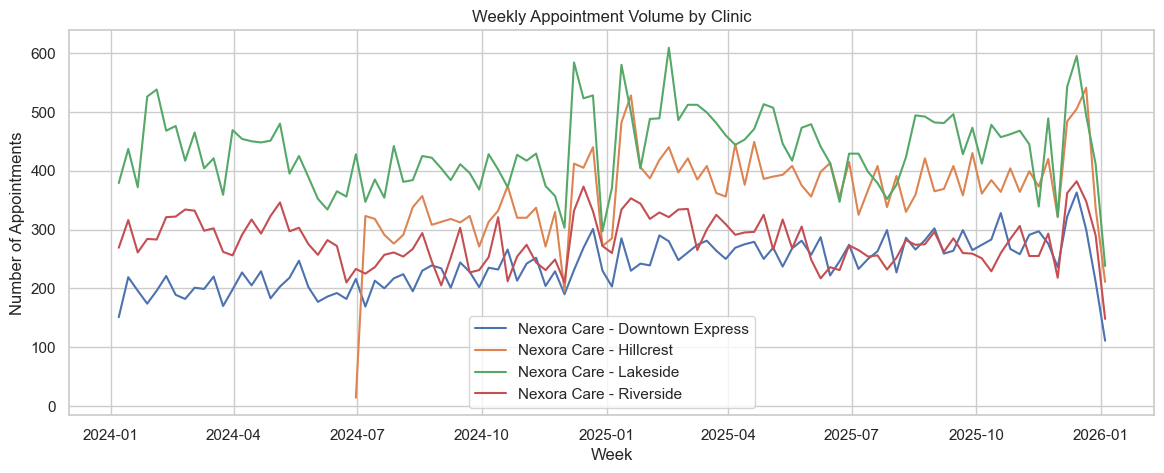

In [33]:
# aggregate to weekly appointment counts, per clinic
weekly = df.groupby(["ClinicName", pd.Grouper(key="AppointmentDateTime", freq="W")]).size().reset_index(name="AppointmentCount")

plt.figure(figsize=(14, 5))
for clinic in weekly["ClinicName"].unique():
    subset = weekly[weekly["ClinicName"] == clinic]
    plt.plot(subset["AppointmentDateTime"], subset["AppointmentCount"], label=clinic)

plt.title("Weekly Appointment Volume by Clinic")
plt.xlabel("Week")
plt.ylabel("Number of Appointments")
plt.legend()
plt.show()

In [34]:
# no-show and cancellation rate per clinic
status_rate = pd.crosstab(df["ClinicName"], df["Status"], normalize="index").round(3) * 100
status_rate

Status,Cancelled,Completed,No-Show,Rescheduled
ClinicName,,,,
Nexora Care - Downtown Express,4.8,84.5,8.6,2.0
Nexora Care - Hillcrest,4.9,84.2,8.8,2.1
Nexora Care - Lakeside,4.8,84.4,8.8,2.0
Nexora Care - Riverside,5.0,84.1,8.8,2.1


## EDA Summary

**Demand drivers identified (Objective 2):**
1. **Day-of-week** — weekdays are broadly similar; Saturday runs at ~half of weekday volume, Sunday at ~a tenth. Strongest, most reliable driver in the dataset.
2. **Holidays** — a near-uniform ~80% drop in volume across all four clinics, regardless of clinic type or size.
3. **Seasonality** — flu season drives 18–27% higher volume at Hillcrest, Lakeside, and Riverside, but has little effect at Downtown Express, which skews heavily toward Telehealth appointments (45.7% vs. 15–21% elsewhere).
4. **Clinic-level differences** — Lakeside is consistently the highest-volume clinic, Downtown Express the lowest; Hillcrest is a newer clinic (live since June 2024) still worth treating as having a shorter usable history.

**Data quality notes carried forward:**
- The final week of the dataset (late Dec 2025) is a partial week and should be excluded from trend/seasonal calculations.
- No-show/cancellation rates are stable and clinic-independent (~84% completed everywhere), useful as a fixed multiplier when converting forecasted bookings into expected staffing need.

**Implication for modeling (Objective 3):** the forecasting model should account for day-of-week and holiday effects uniformly across clinics, but seasonal effects and overall volume level should likely be modeled per clinic (or at least distinguish Downtown Express from the other three) rather than assuming one pattern fits all four.